# Gaming Toxicity Detection

**Authors:** Beibarys Nyussupov, Ruby Ngo, Paola Calle, Jett Forward


In [2]:
# libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

import html as html_lib
from nltk.tokenize import TweetTokenizer

from pathlib import Path
import sys
PROJECT_ROOT = Path().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    
from src.tokenizer import tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import os
import spacy
nlp = spacy.load("en_core_web_sm")
# reproducibility
seed = 7524
np.random.seed(seed)

In [3]:
# data directories
DATA_DIR_WOT  = PROJECT_ROOT / "data/processed_data/wot/"
DATA_DIR_DOTA = PROJECT_ROOT / "data/processed_data/dota/"

## World of Tanks

In [4]:
# load pre-cleaned train/val splits from cleaning notebook
train_df      = pd.read_parquet(DATA_DIR_WOT / "x_train.parquet")
validation_df = pd.read_parquet(DATA_DIR_WOT / "x_validation.parquet")
print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {validation_df.shape}")
print(f"Train first 5 rows:{train_df.head(5)}")

Train shape: (31359, 2)
Validation shape: (9899, 2)
Train first 5 rows:  message  label
0       !    0.0
1       !    0.0
2   ! CAP    0.0
3    !!!!    0.0
4    !!!!    0.0


### Exploratory Data Analysis (EDA)

| Class | Terminology |
|---|---|
| 0 | Non-Toxic |
| 1 | Insults and Flaming |
| 2 | Other Offensive Texts |
| 3 | Hate and Harassment |
| 4 | Threats |
| 5 | Extremism |

#### Class distribution

In [5]:
# class balance check — train set only to avoid val leakage in EDA
print(f"Class distribution:{train_df['label'].value_counts()}")
print(f"Class distribution (normalized):{train_df['label'].value_counts(normalize=True)}")

Class distribution:label
0.0    24899
1.0     4842
2.0     1328
3.0      212
4.0       54
5.0       24
Name: count, dtype: int64
Class distribution (normalized):label
0.0    0.793999
1.0    0.154405
2.0    0.042348
3.0    0.006760
4.0    0.001722
5.0    0.000765
Name: proportion, dtype: float64


C:\Users\nyuss\AppData\Local\Temp\ipykernel_37524\1358053204.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\nyuss\AppData\Local\Temp\ipykernel_37524\1358053204.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


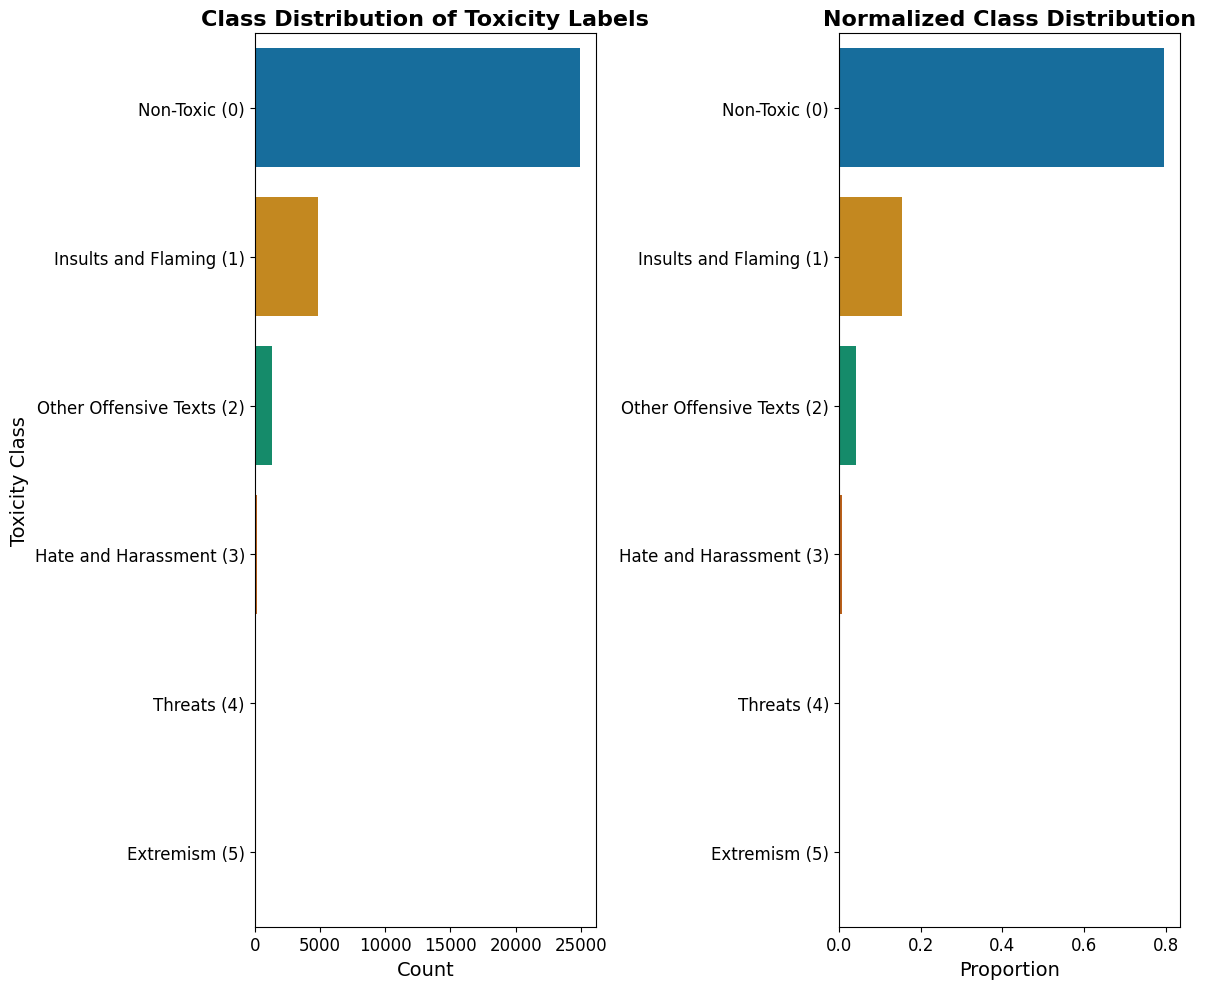

In [6]:
# Class balance plot + normalized class balance plot side by side

# class order and readable labels
class_order = [0, 1, 2, 3, 4, 5]
class_labels = [
    "Non-Toxic (0)",
    "Insults and Flaming (1)",
    "Other Offensive Texts (2)",
    "Hate and Harassment (3)",
    "Threats (4)",
    "Extremism (5)"
]

# map numeric labels to readable names
label_map = dict(zip(class_order, class_labels))
train_df["label_name"] = train_df["label"].map(label_map)

# normalized proportions
class_props = (
    train_df["label"]
    .value_counts(normalize=True)
    .reindex(class_order)
)

# figure
fig, axes = plt.subplots(1, 2, figsize=(12, 10))

# raw counts plot
sns.countplot(
    y="label_name",
    data=train_df,
    order=class_labels,
    palette="colorblind",
    ax=axes[0]
)

# aesthetics
# title 
axes[0].set_title("Class Distribution of Toxicity Labels", fontweight="bold", fontsize=16)

# axis labels and ticks
axes[0].set_xlabel("Count", fontsize=14)
axes[0].set_ylabel("Toxicity Class", fontsize=14)

axes[0].tick_params(axis="y", labelsize=12)
axes[0].tick_params(axis="x", labelsize=12)


# normalized distribution
sns.barplot(
    x=class_props.values,
    y=class_labels,
    palette="colorblind",
    ax=axes[1]
)

# aesthetics 
axes[1].set_title("Normalized Class Distribution", fontweight="bold", fontsize=16)

# axis labels and ticks 
axes[1].set_xlabel("Proportion", fontsize=14)

axes[1].tick_params(axis="y", labelsize=12)
axes[1].tick_params(axis="x", labelsize=12)

plt.tight_layout()
plt.show()

That gives us the idea that the class proportions are very imbalanced. We might experiment with binary vs multiclass classification later because of that. We could also merge minority labels to make it easier for model to learn data signals.

#### Non-English Messages (verification)

In [7]:
import re

NON_LATIN_SCRIPT = re.compile(
    r"[\u0400-\u04FF"   # Cyrillic
    r"\u4E00-\u9FFF"    # CJK unified ideographs
    r"\u3400-\u4DBF"    # CJK extension A
    r"\uF900-\uFAFF"    # CJK compatibility ideographs
    r"\u0600-\u06FF"    # Arabic
    r"\u0590-\u05FF"    # Hebrew
    r"\u3040-\u30FF"    # Japanese (Hiragana + Katakana)
    r"\uAC00-\uD7AF"    # Korean (Hangul syllables)
    r"\u1100-\u11FF"    # Korean (Hangul Jamo)
    r"\u0E00-\u0E7F"    # Thai
    r"\u0900-\u097F"    # Devanagari (Hindi)
    r"\u0980-\u09FF"    # Bengali
    r"\u0370-\u03FF"    # Greek
    r"\u10A0-\u10FF"    # Georgian
    r"\u0530-\u058F"    # Armenian
    r"\u1000-\u109F"    # Myanmar
    r"\u1780-\u17FF]"   # Khmer
)

non_english_count = train_df["message"].str.contains(NON_LATIN_SCRIPT, regex=True, na=False).sum()
print(f"Number of non-English script messages: {non_english_count}")
print(f"Percentage: {(non_english_count / len(train_df)) * 100:.2f}%")

Number of non-English script messages: 0
Percentage: 0.00%


In [8]:
# check
train_df[train_df["message"].str.contains(NON_LATIN_SCRIPT, regex=True, na=False)]

,message,label,label_name


We successfully deleted everything in cleaning phase. 

#### Number of words per document

In [9]:
# summary statistics of comments
print("Summary statistics of comment lengths:")

# create new column with comment world lengths
train_df["comment_length"] = train_df["message"].str.split().str.len()

# summary statistics 
train_describe = train_df["comment_length"].describe()
train_describe 

Summary statistics of comment lengths:


count    31359.000000
mean         3.248669
std          2.526881
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         30.000000
Name: comment_length, dtype: float64

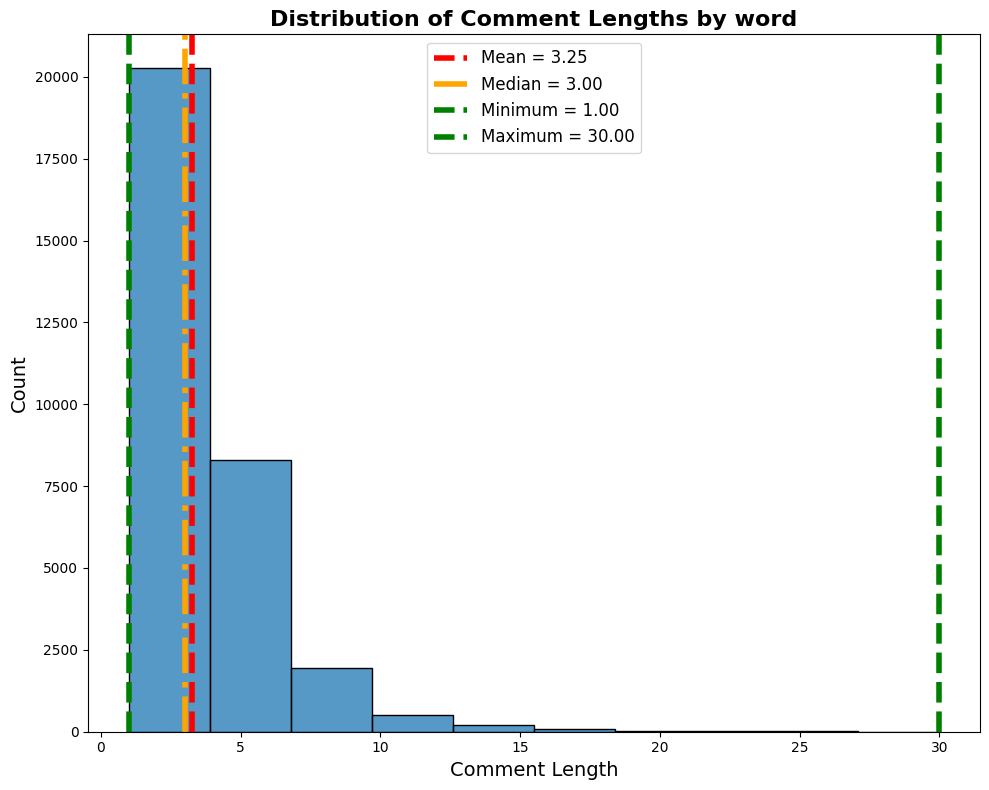

In [10]:
# distribution of world length 
# summary statistics
mean_len = train_df["comment_length"].mean()
median_len = train_df["comment_length"].median()
min_len = train_df["comment_length"].min()
max_len = train_df["comment_length"].max()

# plot
plt.figure(figsize=(10, 8))

# histogram plot
sns.histplot(
    train_df["comment_length"],
    bins=10,
    kde=False
)

# mean line
plt.axvline(
    mean_len,
    linestyle="--",
    linewidth=4,
    label=f"Mean = {mean_len:.2f}", 
    color = "red"
)

# median line
plt.axvline(
    median_len,
    linestyle="-.",
    linewidth=4,
    label=f"Median = {median_len:.2f}",
    color = "orange"
)

# min line 
plt.axvline(
    min_len,
    linestyle="--",
    linewidth=4,
    label=f"Minimum = {min_len:.2f}",
    color = "green"
)

# max line 
plt.axvline(
    max_len,
    linestyle="--",
    linewidth=4,
    label=f"Maximum = {max_len:.2f}",
    color = "green"
)

# title and labels
plt.title("Distribution of Comment Lengths by word", fontweight="bold", fontsize=16)

# xlabel
plt.xlabel("Comment Length", fontsize=14)

# ylabel
plt.ylabel("Count", fontsize=14)

# legend
plt.legend(fontsize=12)

# show the plot 
plt.tight_layout()
plt.show()

Messages are extremely short - median 3 words, max 30 in train data. Over 60% of messages are 1-3 words, confirming that gaming chat is reaction-driven rather than conversational. This justifies unigram + bigram TF-IDF: trigrams would overfit to specific full messages rather than capturing reusable toxic patterns.

In [11]:
# check messages 
# comments longer than or equal to the median top 10 words 
train_df[train_df["comment_length"] >= median_len][["message", "comment_length", "label"]].head(10)

,message,comment_length,label
6,!Siema kto PL Wn8 (300) IQ 6,7,0.0
7,"""If you can‘t take a joke, you shouldn‘t be pl...",12,1.0
8,"""deals too much damage""",4,0.0
9,"""drives premium tank""",3,0.0
19,#Tiger I and IS are camper morns,7,1.0
21,#aoing for me,3,0.0
23,#at 15 there,3,0.0
28,#pedik wk play lego,4,1.0
29,#u outspot them bour,4,0.0
32,% miutes and we win!,5,0.0


In [12]:
# comments longer than or equal to the median bottom 10 words 
train_df[train_df["comment_length"] >= median_len][["message", "comment_length", "label"]].tail(10)

,message,comment_length,label
31333,ı mking vlad,3,0.0
31334,ı warned you rhino,4,0.0
31337,ım noob tier X,4,1.0
31338,ıs-4 don't push pls,4,0.0
31339,ıs6 ıdıot :),3,1.0
31340,ısu+wz+black prince wat are you doing?,6,0.0
31342,šetřil sis to,3,0.0
31345,žyou dudes suck hard,4,1.0
31351,̧907 and strv,3,0.0
31353,‘He probably retreated to forest,5,0.0


This confirms that if we use `trigrams`, the model potentially might overfit to longer sentences without actually capturing the context.

In [13]:
# comments shoterter than the median top 10 words 
train_df[train_df["comment_length"] < median_len][["message", "comment_length", "label"]].head(10)

,message,comment_length,label
0,!,1,0.0
1,!,1,0.0
2,! CAP,2,0.0
3,!!!!,1,0.0
4,!!!!,1,0.0
5,!!!!!!,1,0.0
10,#,1,0.0
11,#4704NUTrition,1,0.0
12,#NAME?,1,0.0
13,#NAME?,1,0.0


In [14]:
# comments shorter than the median bottom 10 words 
train_df[train_df["comment_length"] < median_len][["message", "comment_length", "label"]].tail(10)

,message,comment_length,label
31347,̈IGER !!!,2,0.0
31348,̈chaaaar,1,0.0
31349,̈omfg,1,0.0
31350,̈p,1,0.0
31352,‘FML,1,2.0
31354,‘OMG,1,0.0
31355,‘gj,1,0.0
31356,‘grille,1,0.0
31357,‘omg,1,0.0
31358,‘‘?,1,0.0


#### Word Frequency analysis

In [15]:
# combine all messages
all_text = " ".join(train_df["message"].astype(str))

# tokenize
words = all_text.split()

# frequency table
word_freq = pd.DataFrame(Counter(words).items(), 
                         columns=["word", "count"])
word_freq = word_freq.sort_values(by="count", ascending=False)

# top 20
word_freq.head(20)

,word,count
109,at,1692
12,you,1682
108,Spotted,1420
107,Im,1398
446,the,1345
406,i,1197
242,go,1163
226,to,1039
216,is,919
35,and,819


In [16]:
from src.tokenizer import EXTRA, STOPWORDS

# append with sklearn dictionary
STOPWORDS = STOPWORDS
print(STOPWORDS)

frozenset({'empty', 'bristleback', 'and', 'anything', 'viper', 'next', 'enigma', 'call', 'too', 'nevertheless', 'bloodseeker', 'qop', 'pugna', 'side', 'void', 'hereupon', 'come', 'kv1', 'noone', 'against', 'bh', 'theyre', 'thats', 'move', 'invo', 'have', 'damn', 'onto', 'tiger', 'or', 'undying', 'map', 'okay', 'lich', 'another', 'hereby', 'oracle', 'chieftain', 'waiting', 'whereupon', 'same', 'tbh', 'yep', 'whereby', 'therein', 'alchemist', 'own', 'full', 'three', 'now', 'hers', 'please', 'further', 'meepo', 'amount', 'didnt', 'leshrac', 'sd', 'many', 'him', 'seems', 'ours', 'seem', 'without', 'defender', 'gotta', 'wait', 'such', 'alone', 'already', 'keep', 'vs', 'necrophos', 'techies', 'razor', 'dk', 'mine', 'this', 'anyhow', 'along', 'cry', 'during', 'i', 't62', 'back', 'clinkz', 'themselves', 'after', 'lion', 'today', 'silencer', 'thereby', 'them', 'is7', 'wasnt', 'beforehand', 'slardar', 'thru', 'its', 'an', 'up', 'chen', 'ten', 'twenty', 'been', 'beastmaster', 'sixty', 'detail', '

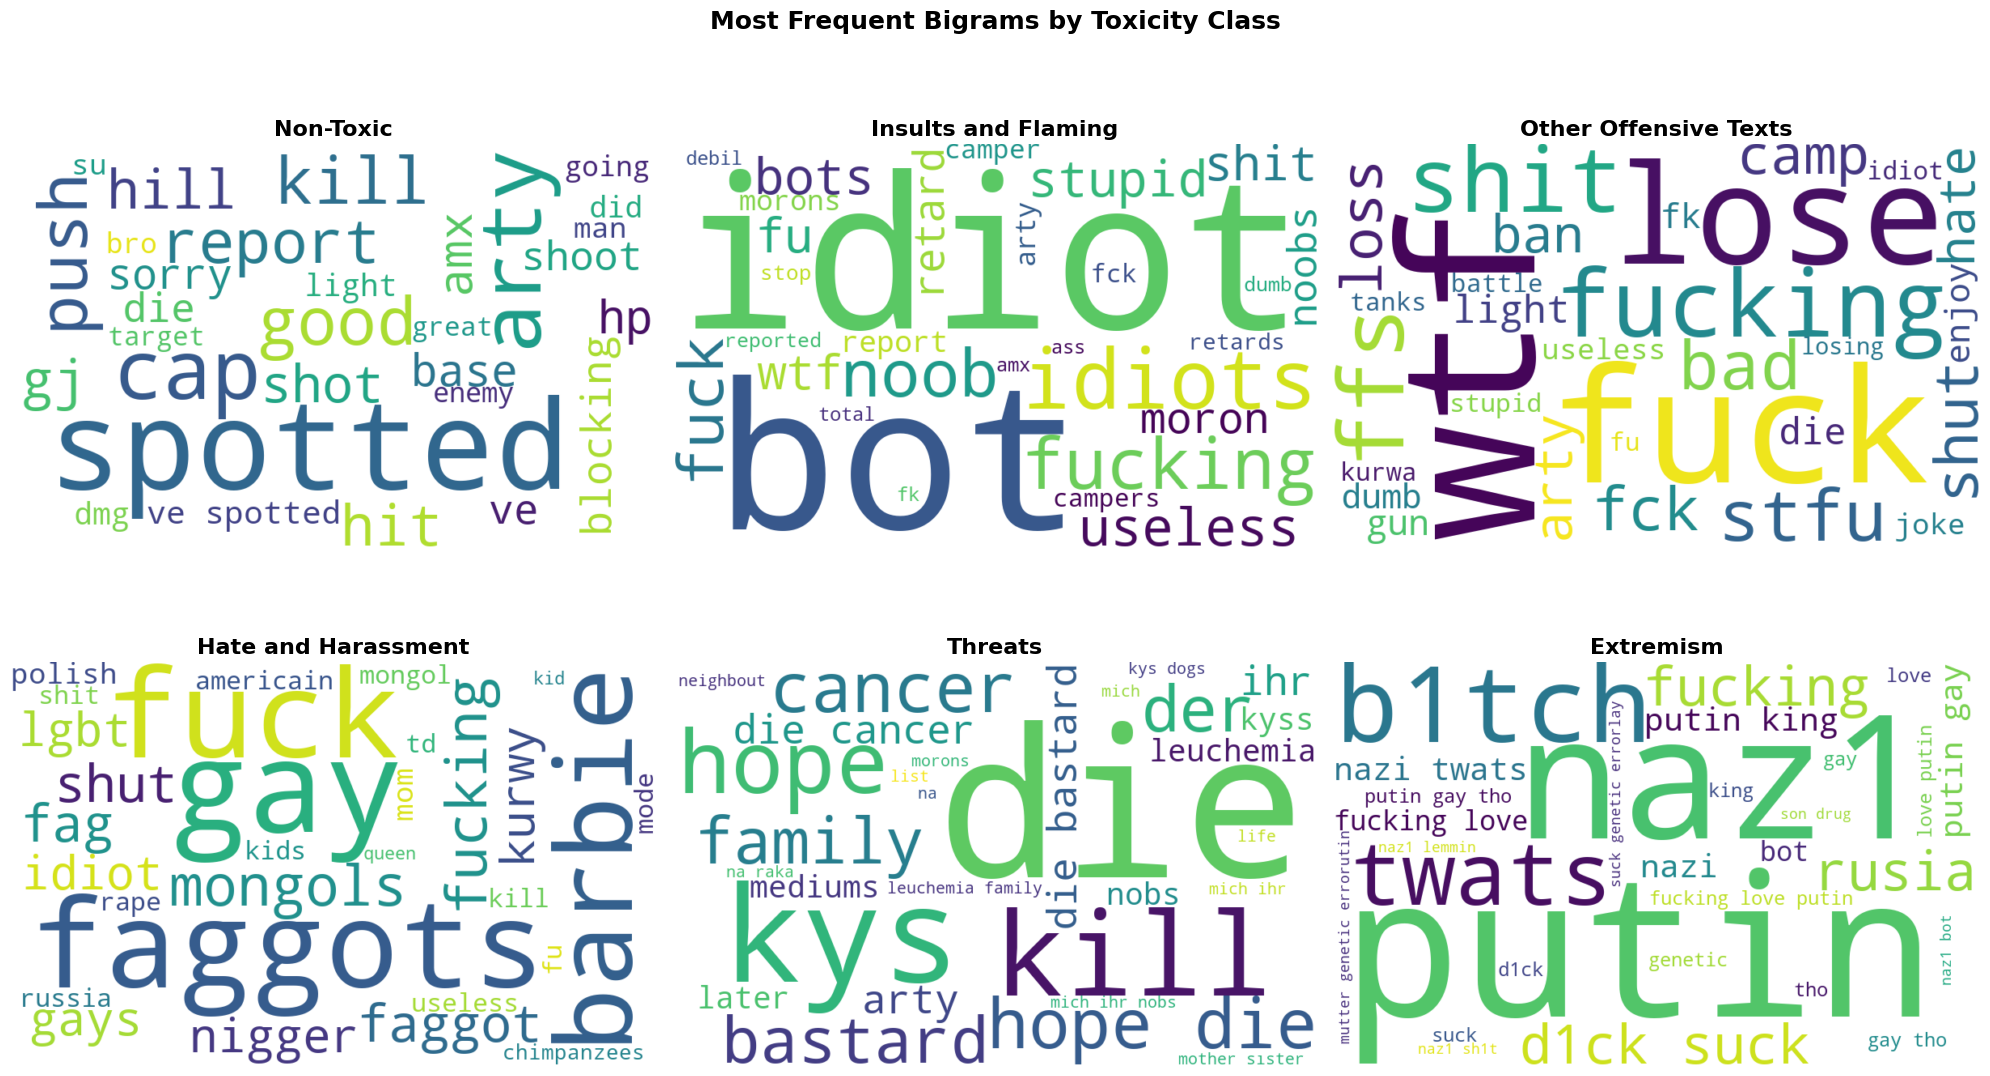

In [17]:
# class map
class_map = {
    0: "Non-Toxic",
    1: "Insults and Flaming",
    2: "Other Offensive Texts",
    3: "Hate and Harassment",
    4: "Threats",
    5: "Extremism"
}



# figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# create world clouds 
for i, cls in enumerate(sorted(train_df["label"].unique())):
    class_text = train_df.loc[train_df["label"] == cls, "message"].astype(str)
    
    # bigram vectorizer 
    bigram_vectorizer = CountVectorizer(
        # normalize accents
        strip_accents = "unicode", 
        # lowercase
        lowercase = True, 
        # stop words
        stop_words = list(STOPWORDS),
        max_df = 0.95,
        # ngram range
        ngram_range= (1, 3))
    
    
    # bigrams
    bigrams_trian = bigram_vectorizer.fit_transform(class_text)
    bigram_counts = bigrams_trian.sum(axis=0).A1
    bigram_names = bigram_vectorizer.get_feature_names_out()
    
    # bigrams frequency 
    bigram_freq_train = pd.DataFrame({
        "bigram": bigram_names,
        "count": bigram_counts
    }).sort_values(by="count", ascending=False).head(30)
    

    if len(bigram_freq_train) > 0:
        bigram_dict = dict(zip(bigram_freq_train["bigram"], 
                                bigram_freq_train["count"]))
        
        # worcloud 
        wordcloud = WordCloud(
            width=800,
            height=500,
            background_color="white"
        ).generate_from_frequencies(bigram_dict)
        
        axes[i].imshow(wordcloud, interpolation="bilinear")
        axes[i].axis("off")
        axes[i].set_title(class_map[cls], fontweight="bold", fontsize=16)
    else:
        axes[i].text(0.5, 0.5, "No bigrams found", ha="center", va="center", fontsize=12)
        axes[i].axis("off")
        axes[i].set_title(class_map[cls], fontweight="bold", fontsize=16)

# design
plt.suptitle("Most Frequent Bigrams by Toxicity Class", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

### Pre-processing

| Feature | TweetTokenizer | Standard (split / CountVectorizer default) |
|---|---|---|
| Handles `@mentions`, `#hashtags` | Keeps as single token | Splits on `#`, `@` |
| Repeated chars (`looool`, `!!!!!!`) | Collapses to max 3 (`loool`, `!!!`) | Keeps full noise |
| Emoticons (`:)`, `:(`) | Preserved as tokens | Broken or dropped |
| Gaming shorthand (`gg`, `wtf`, `xD`) | Preserved as-is | Usually fine but no special handling |
| All-caps preservation | Configurable (`preserve_case`) | Not supported |
| Punctuation inside words | Handles intelligently | Often splits incorrectly |
| Informal language | Designed for it | Designed for formal text |

**Bottom line:** Gaming chat is structurally identical to Twitter - short, informal, abbreviation-heavy, emoticon-rich. TweetTokenizer was built for exactly this domain.


## Dota 2 (CONDA)

In [18]:
# load pre-cleaned train/val splits from cleaning notebook
dota_train_df = pd.read_parquet(DATA_DIR_DOTA / "x_train.parquet")
dota_val_df   = pd.read_parquet(DATA_DIR_DOTA / "x_validation.parquet")
print(f"Train shape: {dota_train_df.shape}")
print(f"Validation shape: {dota_val_df.shape}")
print(f"Train first 5 rows:{dota_train_df.head(5)}")

Train shape: (22404, 2)
Validation shape: (7157, 2)
Train first 5 rows:                                       message  label
0                                         = =?      0
1  THAT LAST PICK SPEC'' LIKE U KNOW SHIT ROFL      1
2                                            !      0
3                                            !      0
4                                            !      0


### Exploratory Data Analysis (EDA)

| Class | Label |
|---|---|
| 0 | Other (non-toxic) |
| 1 | Ego |
| 2 | Aggression |
| 3 | Impolite |

#### Class distribution

In [19]:
# class balance check — train set only
print(f"Class distribution:{dota_train_df['label'].value_counts()}")
print(f"Class distribution (normalized):{dota_train_df['label'].value_counts(normalize=True)}")

Class distribution:label
0    16030
1     3524
2     1528
3     1322
Name: count, dtype: int64
Class distribution (normalized):label
0    0.715497
1    0.157293
2    0.068202
3    0.059007
Name: proportion, dtype: float64


C:\Users\nyuss\AppData\Local\Temp\ipykernel_37524\4118980400.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="label_name", data=dota_train_df, order=class_labels_dota, palette="colorblind", ax=axes[0])
C:\Users\nyuss\AppData\Local\Temp\ipykernel_37524\4118980400.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_props.values, y=class_labels_dota, palette="colorblind", ax=axes[1])


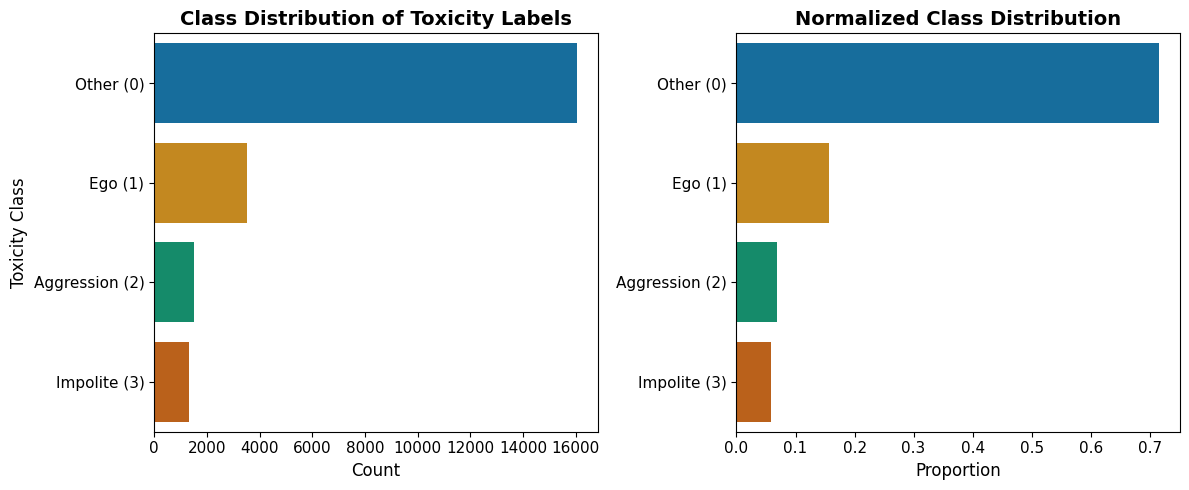

In [21]:
# distribution plot 
class_order_dota  = [0, 1, 2, 3]
class_labels_dota = ["Other (0)", "Ego (1)", "Aggression (2)", "Impolite (3)"]
label_map_dota    = dict(zip(class_order_dota, class_labels_dota))

dota_train_df["label_name"] = dota_train_df["label"].map(label_map_dota)

class_props = dota_train_df["label"].value_counts(normalize=True).reindex(class_order_dota)

# figure size 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# first plot
sns.countplot(y="label_name", data=dota_train_df, order=class_labels_dota, palette="colorblind", ax=axes[0])
axes[0].set_title("Class Distribution of Toxicity Labels", fontweight="bold", fontsize=14)
axes[0].set_xlabel("Count", fontsize=12)
axes[0].set_ylabel("Toxicity Class", fontsize=12)
axes[0].tick_params(labelsize=11)

# second plot
sns.barplot(x=class_props.values, y=class_labels_dota, palette="colorblind", ax=axes[1])
axes[1].set_title("Normalized Class Distribution", fontweight="bold", fontsize=14)
axes[1].set_xlabel("Proportion", fontsize=12)
axes[1].tick_params(labelsize=11)

plt.tight_layout()
plt.show()

The distribution of classes in dota dataset is less imbalanced, but there is still imbalance. We again need to think about potential merging of classes, changing goal to binary classification or testing against multi-classification.

#### Non-English Messages (verification)

Dota 2 is a globally played game - non-ASCII messages are common. We drop them since we are building an English-only classifier.

In [22]:
# check
non_english_count = dota_train_df["message"].str.contains(NON_LATIN_SCRIPT, regex=True, na=False).sum()
print(f"Non-Latin script messages: {non_english_count}")

Non-Latin script messages: 0


Everything's clean.

#### Word Frequency Analysis

#### Number of words per document

In [25]:
# summary statistics of comment lengths
print("Summary statistics of comment lengths:")
dota_train_df["comment_length"] = dota_train_df["message"].str.split().str.len()
dota_train_df["comment_length"].describe()

Summary statistics of comment lengths:


count    22404.000000
mean         3.733039
std          3.319580
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         41.000000
Name: comment_length, dtype: float64

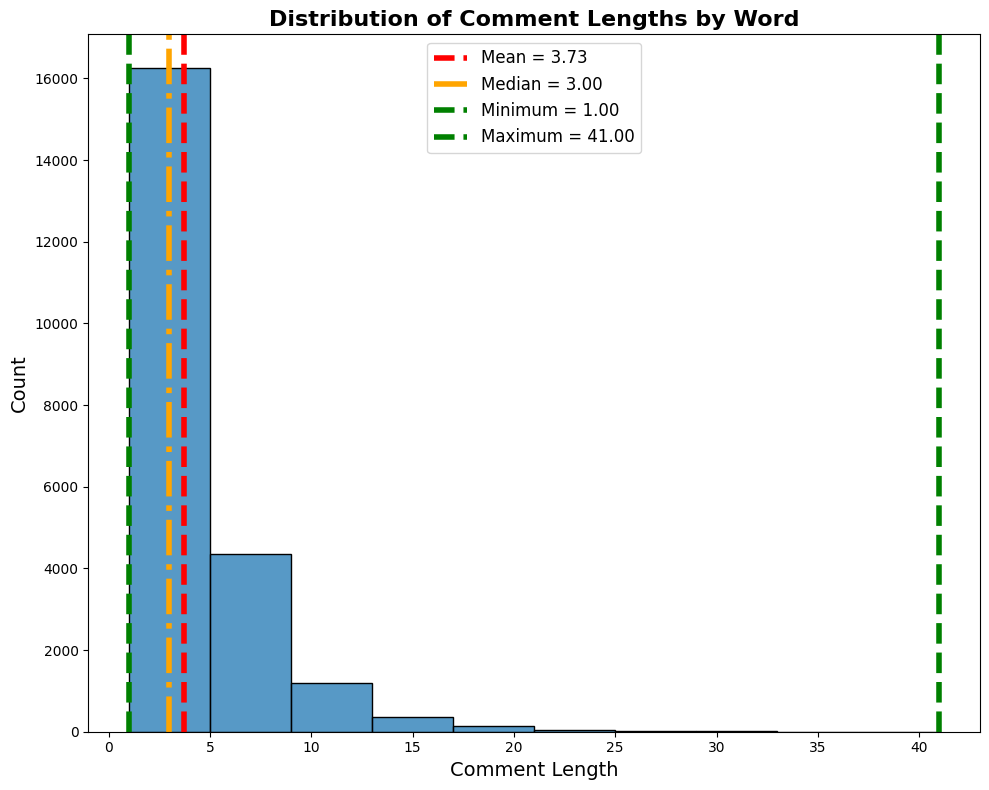

In [26]:
# distribution of comment lengths by word
mean_len   = dota_train_df["comment_length"].mean()
median_len = dota_train_df["comment_length"].median()
min_len    = dota_train_df["comment_length"].min()
max_len    = dota_train_df["comment_length"].max()

plt.figure(figsize=(10, 8))
sns.histplot(dota_train_df["comment_length"], bins=10, kde=False)

plt.axvline(mean_len,   linestyle="--", linewidth=4, label=f"Mean = {mean_len:.2f}",    color="red")
plt.axvline(median_len, linestyle="-.", linewidth=4, label=f"Median = {median_len:.2f}", color="orange")
plt.axvline(min_len,    linestyle="--", linewidth=4, label=f"Minimum = {min_len:.2f}",  color="green")
plt.axvline(max_len,    linestyle="--", linewidth=4, label=f"Maximum = {max_len:.2f}",  color="green")

plt.title("Distribution of Comment Lengths by Word", fontweight="bold", fontsize=16)
plt.xlabel("Comment Length", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

Again, we can see than mean and median number of words in each message is ~3. We will utilize unigrams/bigrams for dota dataset as well.

In [27]:
# comments longer than or equal to the median top 10 words
dota_train_df[dota_train_df["comment_length"] >= median_len][["message", "comment_length", "label"]].head(10)

,message,comment_length,label
1,THAT LAST PICK SPEC'' LIKE U KNOW SHIT ROFL,9,1
8,! min more Rc,4,2
15,!@#!@#!@# !@#!#!@#!@# #!@#!@#!@,3,0
33,#Reported 10 days a week fking idiots ive done...,23,1
50,$K DONe 4k done :),5,0
53,& they are not talking naw & lost of not so?>,11,0
71,( but i dont know what i can do ( fucking 3k mmr,13,1
76,() EZ DOOM,3,3
87,(: Sf serious question how u lose mid to ember...,13,0
88,(: give n take friendship ez friend,7,3


In [28]:
# comments longer than or equal to the median bottom 10 words
dota_train_df[dota_train_df["comment_length"] >= median_len][["message", "comment_length", "label"]].tail(10)

,message,comment_length,label
22301,é lixo fiz oq pud nucna vi um aa joga tanto co...,12,0
22304,ı donno to :D,4,0
22318, Sry clinkz,3,0
22321, no fun streamers online so boring,7,0
22322, so how is your day?,6,0
22341, tfw 10 min disconnect  tfw viper lies ,10,0
22364, putin and vodka,4,0
22385, WP guys,3,0
22396,ｈａｈａｈ Ｌｍａｏ ｖｉｖａ ｌａ ｐｅｒｕ ｖｉｖａ ｌａ ｇｙｒｏ,8,1
22403,ｓｔｏｐ ｔｒｙｉｎｇ ｔｏ ｓｐｅａｋ ｅｎｇｌｉｓｈ ｐｅｒｕ,6,1


In [29]:
# comments shorter than the median top 10 words
dota_train_df[dota_train_df["comment_length"] < median_len][["message", "comment_length", "label"]].head(10)

,message,comment_length,label
0,= =?,2,0
2,!,1,0
3,!,1,0
4,!,1,0
5,!,1,0
6,!,1,0
7,!,1,0
9,!!,1,0
10,!!!,1,0
11,!!!!,1,0


In [30]:
# comments shorter than the median bottom 10 words
dota_train_df[dota_train_df["comment_length"] < median_len][["message", "comment_length", "label"]].tail(10)

,message,comment_length,label
22392,？,1,0
22393,Ｕ ＯＫ＿,2,0
22394,ＸＤＸＤＸ ＬＦＭＡＯ,2,0
22395,ｇｇ,1,0
22397,ｋａｋ ｄｅｌａ,2,0
22398,ｌＭＡＯ,1,0
22399,ｌｋｍｆａｏ,1,0
22400,ｏｈ,1,0
22401,ｓｈｅ？！,1,0
22402,ｓｉｓｉｓｉｎｇ gg,2,0


Messages are extremely short - median 2 words, max ~51 in train data. Dota 2 chat mirrors WoT: reaction-driven, not conversational. This confirms unigram + bigram TF-IDF is the right choice - trigrams would overfit to specific full messages rather than capturing reusable toxic patterns.

In [31]:
# top 20 most frequent words in training set
all_text = " ".join(dota_train_df["message"].astype(str))
words = all_text.split()

word_freq = pd.DataFrame(Counter(words).items(), columns=["word", "count"])
word_freq = word_freq.sort_values(by="count", ascending=False)
word_freq.head(20)

,word,count
88,i,1172
108,u,1160
490,you,1001
119,ez,745
145,is,719
33,a,697
173,report,697
140,gg,691
307,the,683
300,me,655


In [32]:
# stopwords dictionary 
from src.tokenizer import EXTRA, STOPWORDS

# append with sklearn dictionary
STOPWORDS = STOPWORDS # frozenset, O(1) lookup
print(STOPWORDS)

frozenset({'empty', 'bristleback', 'and', 'anything', 'viper', 'next', 'enigma', 'call', 'too', 'nevertheless', 'bloodseeker', 'qop', 'pugna', 'side', 'void', 'hereupon', 'come', 'kv1', 'noone', 'against', 'bh', 'theyre', 'thats', 'move', 'invo', 'have', 'damn', 'onto', 'tiger', 'or', 'undying', 'map', 'okay', 'lich', 'another', 'hereby', 'oracle', 'chieftain', 'waiting', 'whereupon', 'same', 'tbh', 'yep', 'whereby', 'therein', 'alchemist', 'own', 'full', 'three', 'now', 'hers', 'please', 'further', 'meepo', 'amount', 'didnt', 'leshrac', 'sd', 'many', 'him', 'seems', 'ours', 'seem', 'without', 'defender', 'gotta', 'wait', 'such', 'alone', 'already', 'keep', 'vs', 'necrophos', 'techies', 'razor', 'dk', 'mine', 'this', 'anyhow', 'along', 'cry', 'during', 'i', 't62', 'back', 'clinkz', 'themselves', 'after', 'lion', 'today', 'silencer', 'thereby', 'them', 'is7', 'wasnt', 'beforehand', 'slardar', 'thru', 'its', 'an', 'up', 'chen', 'ten', 'twenty', 'been', 'beastmaster', 'sixty', 'detail', '

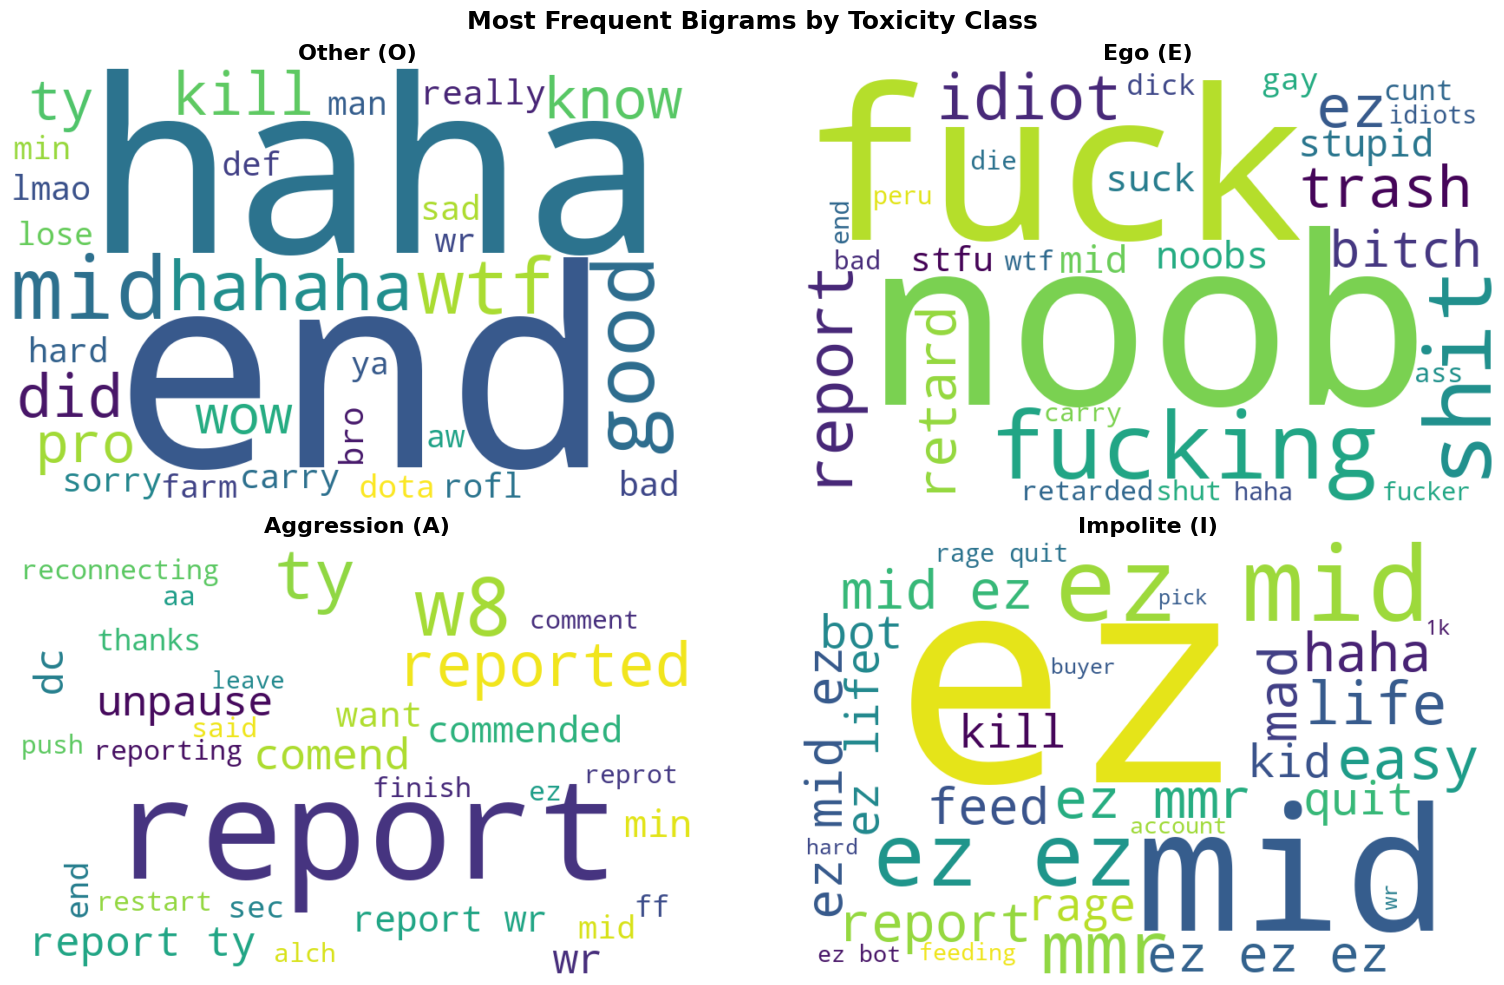

In [33]:
# same cloud plot for Dota dataset
class_map_dota = {0: "Other (O)", 1: "Ego (E)", 2: "Aggression (A)", 3: "Impolite (I)"}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, cls in enumerate(sorted(dota_train_df["label"].unique())):
    class_text = dota_train_df.loc[dota_train_df["label"] == cls, "message"].astype(str)

    bigram_vectorizer = CountVectorizer(
        strip_accents="unicode",
        lowercase=True,
        stop_words=list(STOPWORDS),
        max_df=0.95,
        ngram_range=(1, 3)
    )

    bigrams_train = bigram_vectorizer.fit_transform(class_text)
    bigram_counts = bigrams_train.sum(axis=0).A1
    bigram_names  = bigram_vectorizer.get_feature_names_out()

    bigram_freq_train = pd.DataFrame({
        "bigram": bigram_names,
        "count":  bigram_counts
    }).sort_values(by="count", ascending=False).head(30)

    if len(bigram_freq_train) > 0:
        bigram_dict = dict(zip(bigram_freq_train["bigram"], bigram_freq_train["count"]))
        wordcloud = WordCloud(width=800, height=500, background_color="white").generate_from_frequencies(bigram_dict)
        axes[i].imshow(wordcloud, interpolation="bilinear")
        axes[i].axis("off")
        axes[i].set_title(class_map_dota[cls], fontweight="bold", fontsize=16)
    else:
        axes[i].text(0.5, 0.5, "No bigrams found", ha="center", va="center", fontsize=12)
        axes[i].axis("off")
        axes[i].set_title(class_map_dota[cls], fontweight="bold", fontsize=16)

plt.suptitle("Most Frequent Bigrams by Toxicity Class", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

The classes are well-separated. Other (non-toxic) uses coordination language (gg, wp, nice). Ego centers on boasting and blame directed at teammates. Aggression uses direct insults and profanity. Impolite uses mild rudeness without explicit slurs - the most ambiguous class and hardest to distinguish from Ego.

- **Signals:**
    - Other (O): gg, wp, kill, carry, hard, bad, wtf - neutral game outcomes + sportsmanship

    - Ego (E): noob, fuck, fucking, shit, idiot, retard - skill attacks

    - Aggression (A): report, reported, reporting - behavior complaints dominate clearly

    - Impolite (I): ez, mid, easy, bot, life, kid, rage - condescension

### Pre-processing

Same TweetTokenizer pipeline as WoT - Dota 2 chat is structurally identical: short, informal, abbreviation-heavy. All-caps words (`REPORT`, `GG`) preserved for expressive intensity.